## Diseño de PID mediante LGR para la planta termica

Partimos desde la función de transferencia de lazo abierto ($G_{PID}(s)$) y nuestra funcion de transferencia de planta termica ($G(s)$):

$$ G_{PID}(S) = K_p (1 + \frac{1}{T_i s} + T_d s) $$

$$ G(S) = \frac{K}{\tau s + 1} e^{\theta_d s} $$

Hacemos la comprobación de nuestra función de lazo cerrado $ L(s) $

$$ L(s) = G_{PID}(s) G(s) =  K_p (1 + \frac{1}{T_i s} + T_d s) \ \frac{K}{\tau s + 1} $$

In [115]:
import control as ctrl
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

Comprobación del codigo

## Trazado de Lugar Geométrico de las Raíces

Procedemos a gráficar el lugar geométrico de las raíces de $L(s)$, variando $K_p$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


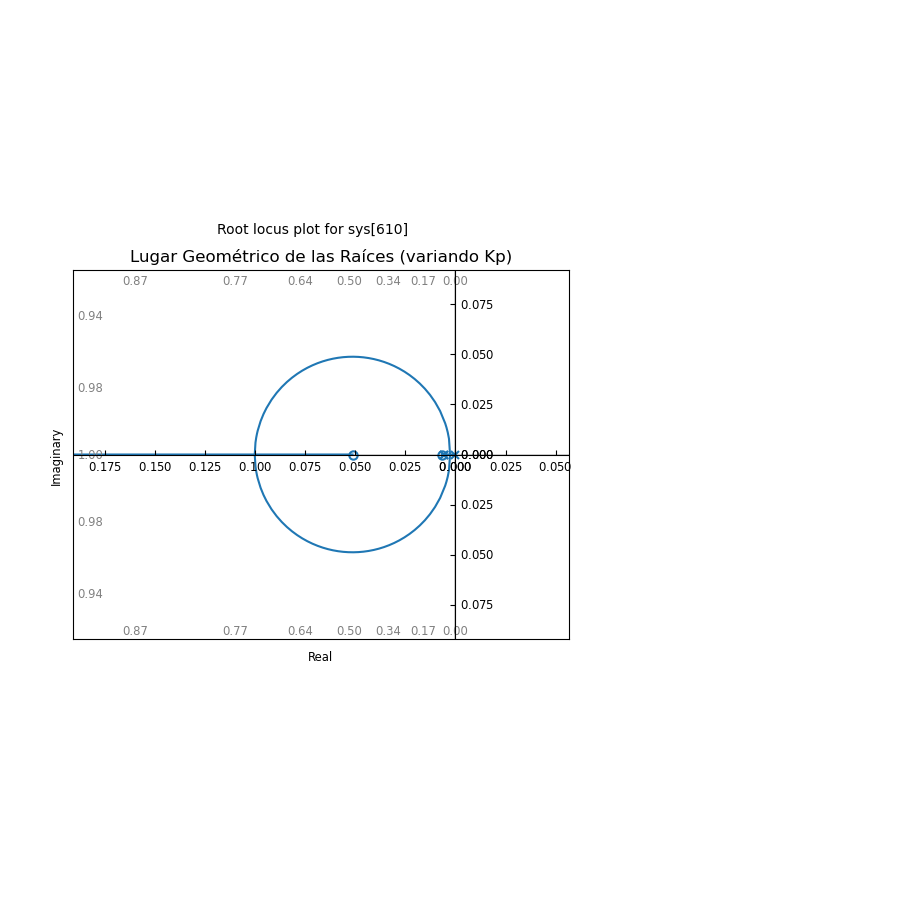

Kp = 0.5, polos = [-0.00636807+0.j         -0.00275421+0.00277159j -0.00275421-0.00277159j]
Kp = 1, polos = [-0.00642944+0.j        -0.00286836+0.0046921j -0.00286836-0.0046921j]
Kp = 2, polos = [-0.00313674+0.00708869j -0.00313674-0.00708869j -0.00647202+0.j        ]
Kp = 5, polos = [-0.00398975+0.01155701j -0.00398975-0.01155701j -0.00650401+0.j        ]
Kp = 17.68, polos = [-0.00765391+0.02164605j -0.00765391-0.02164605j -0.00652174+0.j        ]


In [116]:
K = 1
tau = 172.61

Ti = tau
Td = tau / 10

# Sistema sin Kp
num = [Td * Ti, Ti, 1]
den = [Ti * tau, Ti, 0]

C_base = ctrl.tf(num, den)
G = ctrl.tf([K], [tau, 1])

L_base = C_base * G

# Root locus (Kp variable automáticamente)
plt.figure()
ctrl.root_locus(L_base)
plt.title('Lugar Geométrico de las Raíces (variando Kp)')
plt.grid()
plt.show()

#Grafica step response acorde al cambio de Kp


Kp_values = [0.5, 1, 2, 5, 17.68]

for Kp in Kp_values:
    L = Kp * L_base
    T = ctrl.feedback(L, 1)
    print(f"Kp = {Kp}, polos = {ctrl.poles(T)}")


In [117]:
# Especificaciones
OS = 10          # % sobreimpulso
Ts = 120         # tiempo de asentamiento (s)

# -----------------------------
# 1. Calcular zeta
# -----------------------------
zeta = -np.log(OS/100) / np.sqrt(np.pi**2 + (np.log(OS/100))**2)

# -----------------------------
# 2. Calcular frecuencia natural wn
# -----------------------------
wn = 4 / (zeta * Ts)

# -----------------------------
# 3. Calcular polos deseados
# -----------------------------
sigma = -zeta * wn
wd = wn * np.sqrt(1 - zeta**2)

s1 = complex(sigma, wd)
s2 = complex(sigma, -wd)

print("zeta =", zeta)
print("wn =", wn)
print("s1 =", s1)
print("s2 =", s2)

zeta = 0.5911550337988976
wn = 0.05638678760650266
s1 = (-0.03333333333333334+0.045479211794728046j)
s2 = (-0.03333333333333334-0.045479211794728046j)


## Calculo de Ti, Td

In [118]:
# Vars
Ti, Td = sp.symbols('Ti Td', real=True)

# Datos
Kp = 10.45
tau = 172.61

# Polo deseado
s = s1

# Definir L(s)
num = Ti*Td*s**2 + Ti*s + 1
den = Ti*s*(tau*s + 1)

L = Kp * num / den

# -----------------------------
# ECUACIÓN 1: fase → Im(L) = 0
# -----------------------------
eq1 = sp.im(L)

# -----------------------------
# ECUACIÓN 2: módulo → |L| = 1
# -----------------------------
eq2 = sp.re(L)**2 + sp.im(L)**2 - 1

# -----------------------------
# Intentar resolver
# -----------------------------
sol = sp.nsolve(
    [eq1, eq2],
    [Ti, Td],
    [100, 10],  # intenta también otros iniciales
    tol=1e-6,   # relajar tolerancia
    maxsteps=100
)

# Problemas de metodo de optimización
print("Ti =", float(sol[0]))
print("Td =", float(sol[1]))

Ti = 19.136601391128856
Td = -0.08229764888557388


In [119]:
Ti_val = float(sol[0])
Td_val = float(sol[1])

sd = s1

num = Ti_val*Td_val*sd**2 + Ti_val*sd + 1
den = Ti_val*sd*(tau*sd + 1)

L_val = Kp * num / den

print("Magnitud:", abs(L_val))
print("Fase (deg):", np.degrees(np.angle(L_val)))

Magnitud: 1.0000000894552714
Fase (deg): 179.99999679080557


## Simulación y Verificación

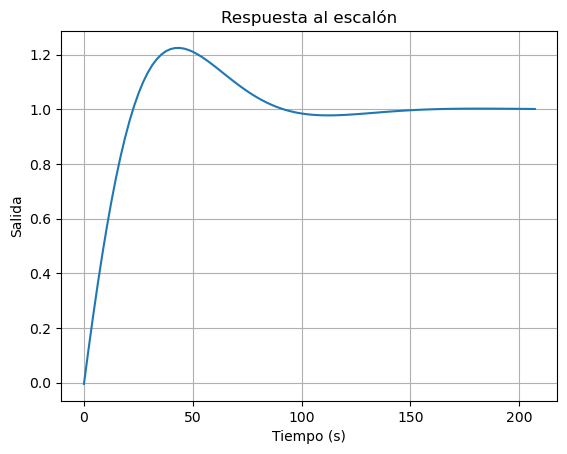

Sobreimpulso (%OS): 22.433225291322294
Tiempo de asentamiento Ts (s): 123.50228385086189
Tiempo de subida: 18.839331434877238
Close loop poles: [-0.03333334+0.04547921j -0.03333334-0.04547921j]
Close loop poles desired: (-0.03333333333333334+0.045479211794728046j)


In [120]:
# Tus valores obtenidos
tau = 172.61

Ti = Ti_val
Td = Td_val

# Controlador PID
numC = [Kp*Td*Ti, Kp*Ti, Kp]
denC = [Ti, 0]

C = ctrl.tf(numC, denC)

# Planta
G = ctrl.tf([1], [tau, 1])

# Lazo abierto
L = C * G

# Lazo cerrado
T = ctrl.feedback(L, 1)

t, y = ctrl.step_response(T)

plt.figure()
plt.plot(t, y)
plt.title("Respuesta al escalón")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
#plt.ylim(0, 1.5)
plt.grid()
plt.show()

info = ctrl.step_info(T)

print("Sobreimpulso (%OS):", info['Overshoot'])
print("Tiempo de asentamiento Ts (s):", info['SettlingTime'])
print("Tiempo de subida:", info['RiseTime'])
print("Close loop poles:", ctrl.poles(T))
print("Close loop poles desired:", s)

# 60 - 120 segundos